# 🏦 Credit Risk Analysis

Bu proje, kredi temerrüt riskini tahmin etmek amacıyla gerçek banka verisi 
simülasyonu üzerinde makine öğrenmesi modelleri geliştirmeyi amaçlamaktadır.

## Proje Adımları
- Keşifsel Veri Analizi (EDA)
- İstatistiksel Testler (T-testi, Ki-Kare)
- Veri Ön İşleme
- Logistic Regression ve Random Forest Modelleri
- Model Değerlendirme (ROC-AUC: 0.93)

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/laotse/credit-risk-dataset/credit_risk_dataset.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/kaggle/input/datasets/laotse/credit-risk-dataset/credit_risk_dataset.csv")

print("Shape:", df.shape)
print("\nSütunlar:", df.columns.tolist())
print("\nEksik değerler:\n", df.isnull().sum())
print("\nHedef değişken dağılımı:")
print(df['loan_status'].value_counts())

Shape: (32581, 12)

Sütunlar: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']

Eksik değerler:
 person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Hedef değişken dağılımı:
loan_status
0    25473
1     7108
Name: count, dtype: int64


In [4]:
#Sayısal değişkenlerin dağılımı
df.describe().round(2)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.00,32581.00,31686.00,32581.00,29465.00,32581.00,32581.00,32581.00
mean,27.73,66074.85,4.79,9589.37,11.01,0.22,0.17,5.80
std,6.35,61983.12,4.14,6322.09,3.24,0.41,0.11,4.06
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,38500.00,2.00,5000.00,7.90,0.00,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,79200.00,7.00,12200.00,13.47,0.00,0.23,8.00
max,144.00,6000000.00,123.00,35000.00,23.22,1.00,0.83,30.00


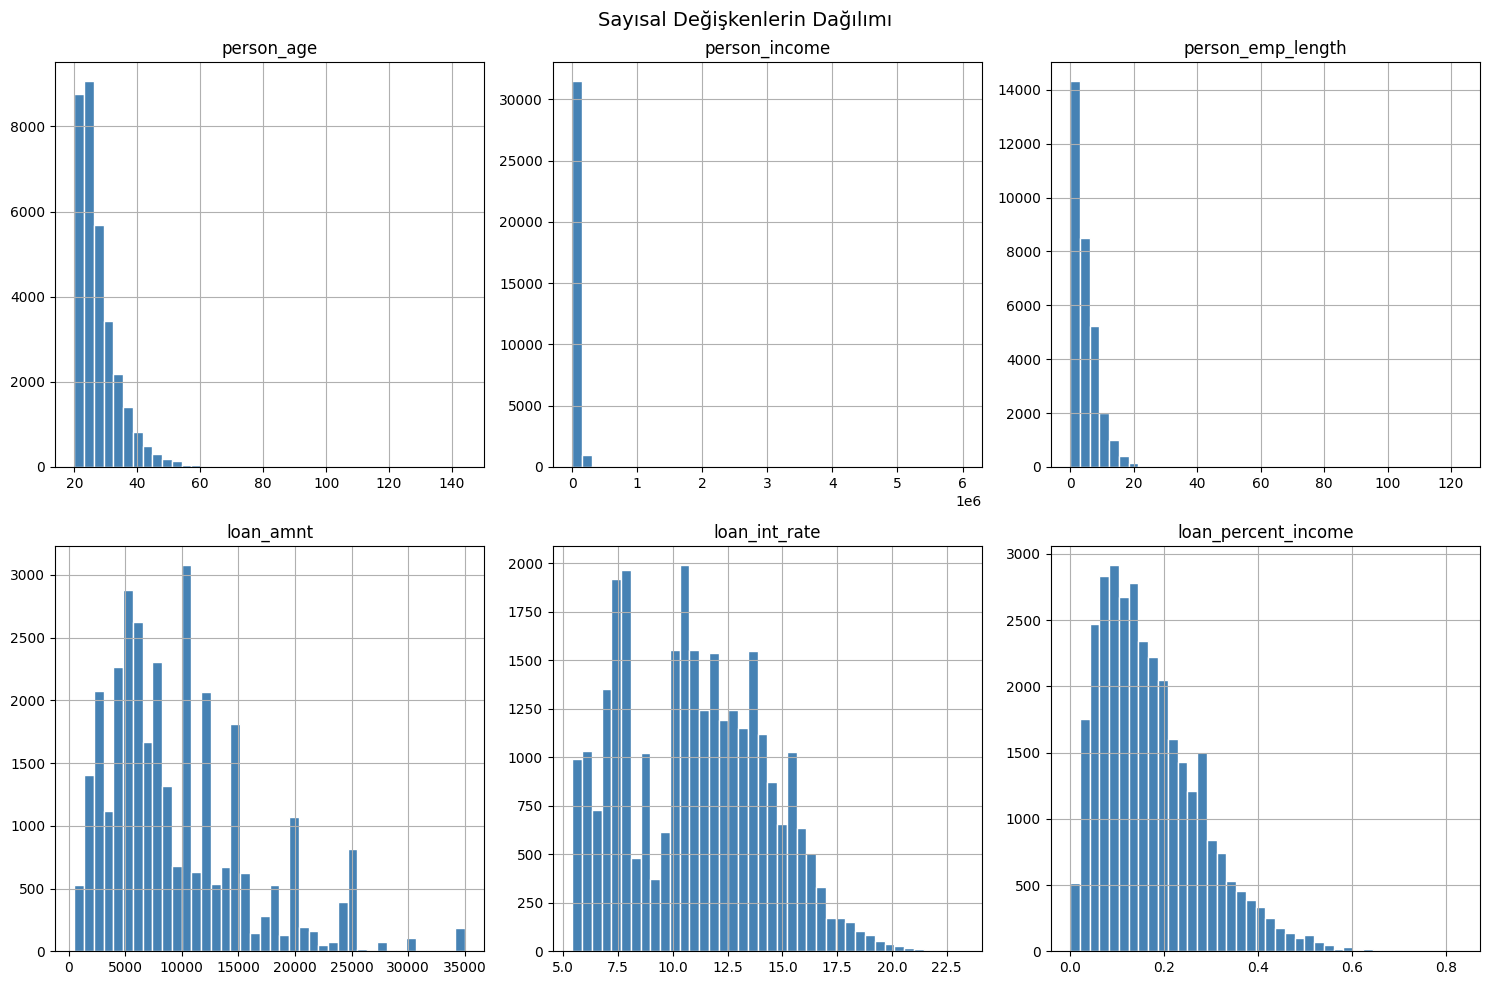

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

cols = ['person_age', 'person_income', 'person_emp_length', 
        'loan_amnt', 'loan_int_rate', 'loan_percent_income']

for i, col in enumerate(cols):
    ax = axes[i//3, i%3]
    df[col].hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('')

plt.suptitle('Sayısal Değişkenlerin Dağılımı', fontsize=14)
plt.tight_layout()
plt.show()

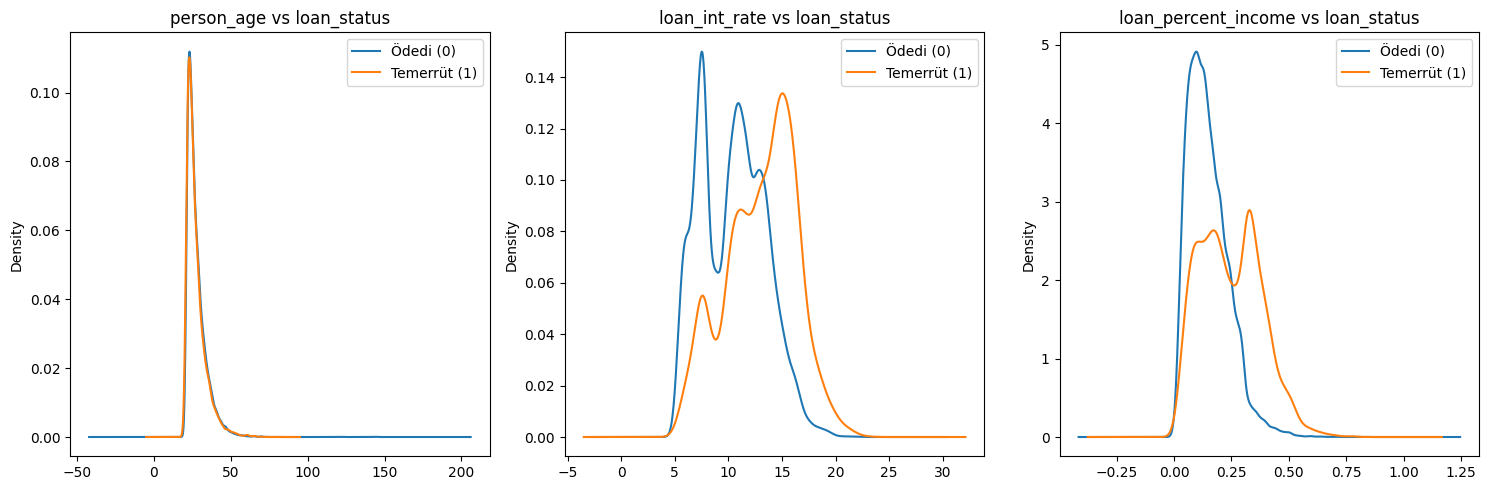

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(['person_age', 'loan_int_rate', 'loan_percent_income']):
    df.groupby('loan_status')[col].plot(kind='kde', ax=axes[i], legend=True)
    axes[i].set_title(f'{col} vs loan_status')
    axes[i].legend(['Ödedi (0)', 'Temerrüt (1)'])

plt.tight_layout()
plt.show()

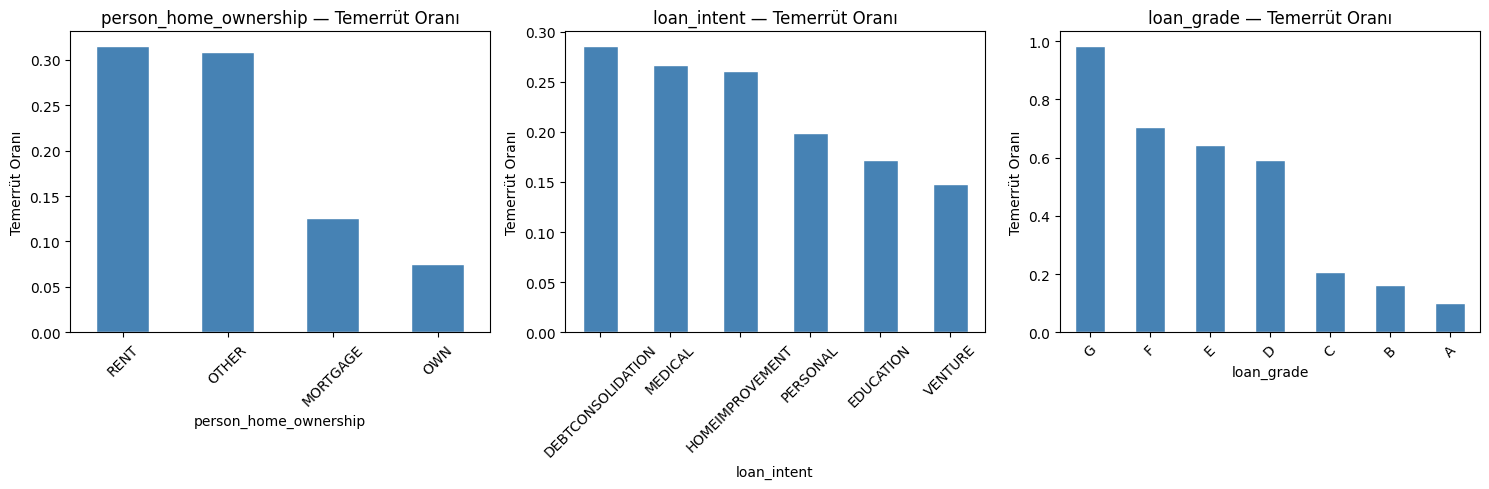

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade']

for i, col in enumerate(cat_cols):
    ct = df.groupby(col)['loan_status'].mean().sort_values(ascending=False)
    ct.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col} — Temerrüt Oranı')
    axes[i].set_ylabel('Temerrüt Oranı')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [8]:
from scipy import stats

# loan_int_rate için t-testi: temerrüt edenler vs etmeyenler
group0 = df[df['loan_status'] == 0]['loan_int_rate'].dropna()
group1 = df[df['loan_status'] == 1]['loan_int_rate'].dropna()

t_stat, p_value = stats.ttest_ind(group0, group1)

print(f"Grup 0 (Ödedi) ortalama faiz: {group0.mean():.2f}%")
print(f"Grup 1 (Temerrüt) ortalama faiz: {group1.mean():.2f}%")
print(f"T-istatistiği: {t_stat:.4f}")
print(f"P-değeri: {p_value:.6f}")
print("\nSonuç:", "İstatistiksel olarak anlamlı fark var ✅" if p_value < 0.05 else "Fark anlamlı değil ❌")

Grup 0 (Ödedi) ortalama faiz: 10.44%
Grup 1 (Temerrüt) ortalama faiz: 13.06%
T-istatistiği: -61.0556
P-değeri: 0.000000

Sonuç: İstatistiksel olarak anlamlı fark var ✅


In [9]:
from scipy.stats import chi2_contingency

# loan_grade ile loan_status arasında ki-kare testi
ct = pd.crosstab(df['loan_grade'], df['loan_status'])
chi2, p, dof, expected = chi2_contingency(ct)

print(f"Ki-Kare istatistiği: {chi2:.2f}")
print(f"Serbestlik derecesi: {dof}")
print(f"P-değeri: {p:.6f}")
print("\nSonuç:", "İstatistiksel olarak anlamlı ilişki var ✅" if p < 0.05 else "İlişki anlamlı değil ❌")

Ki-Kare istatistiği: 5609.18
Serbestlik derecesi: 6
P-değeri: 0.000000

Sonuç: İstatistiksel olarak anlamlı ilişki var ✅


In [10]:
# 1. Aykırı değerleri temizle
df_clean = df[df['person_age'] < 100].copy()
df_clean = df_clean[df_clean['person_emp_length'] < 60]
df_clean = df_clean[df_clean['person_income'] < 1_000_000]

# 2. Eksik değerleri doldur
df_clean['loan_int_rate'].fillna(df_clean['loan_int_rate'].median(), inplace=True)
df_clean['person_emp_length'].fillna(df_clean['person_emp_length'].median(), inplace=True)

# 3. Kategorik değişkenleri encode et
df_clean = pd.get_dummies(df_clean, columns=['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file'])

print("Temizlenmiş veri shape:", df_clean.shape)
print("Eksik değer kaldı mı:", df_clean.isnull().sum().sum())

Temizlenmiş veri shape: (31671, 27)
Eksik değer kaldı mı: 0


/tmp/ipykernel_55/3258820402.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['loan_int_rate'].fillna(df_clean['loan_int_rate'].median(), inplace=True)
/tmp/ipykernel_55/3258820402.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].meth

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# X ve y ayır
X = df_clean.drop('loan_status', axis=1)
y = df_clean['loan_status']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_sc, y_train)
lr_pred = lr.predict(X_test_sc)

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:,1]).round(4))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.88      0.95      0.92      4940
           1       0.76      0.55      0.64      1395

    accuracy                           0.86      6335
   macro avg       0.82      0.75      0.78      6335
weighted avg       0.85      0.86      0.85      6335

ROC-AUC: 0.8645


In [12]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]).round(4))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.92      0.99      0.96      4940
           1       0.97      0.70      0.81      1395

    accuracy                           0.93      6335
   macro avg       0.95      0.85      0.89      6335
weighted avg       0.93      0.93      0.93      6335

ROC-AUC: 0.9263


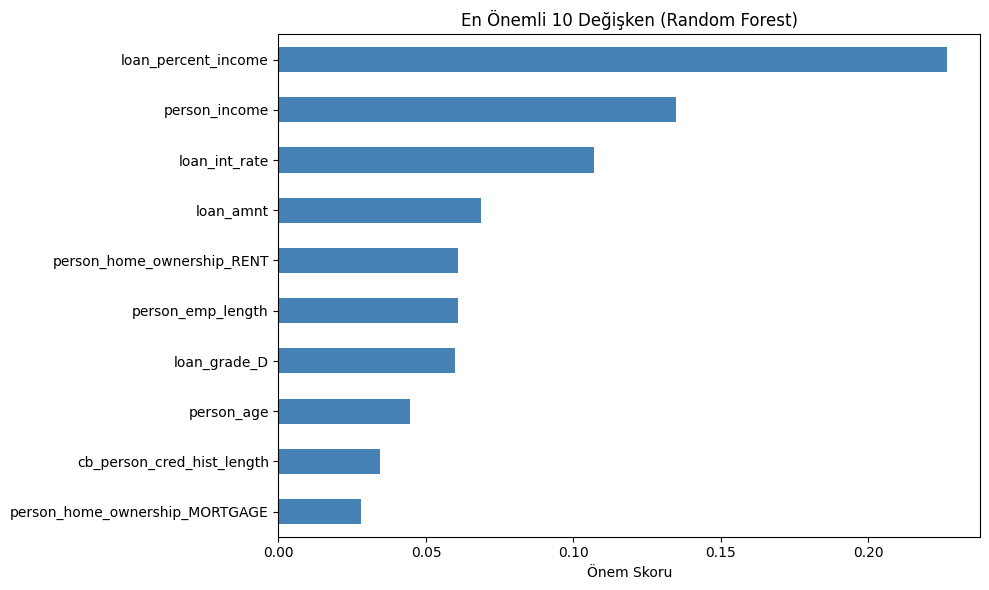

In [13]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.nlargest(10).sort_values().plot(kind='barh', figsize=(10, 6), color='steelblue')
plt.title('En Önemli 10 Değişken (Random Forest)')
plt.xlabel('Önem Skoru')
plt.tight_layout()
plt.show()